# Notebook Contents

- Loading data for torch
- Using Pytorch


# Loading in the Data
In this example, we are going to use crossed columns and embedding columns inside of a tensorflow object created with keras.

However, we will start the process by loading up a dataset with a mix of categorical data and numeric data. This dataset is quite old and has been used many times in machine learning examples: the census data from 1990's. We will use it to predict if a person will earn over or under 50k per year.

- https://archive.ics.uci.edu/ml/datasets/Census-Income+(KDD)
- This data goes by various name, including the "Adult" dataset and 1996 Census data

In [1]:
import pandas as pd

headers = ['age','workclass','fnlwgt','education','edu_num','marital_status',
           'occupation','relationship','race','sex','cap_gain','cap_loss','work_hrs_weekly','country','income']
df_train_orig = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data',names=headers)
df_test_orig = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test',names=headers)
df_test_orig = df_test_orig.iloc[1:]
print(df_train_orig.info())

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              32561 non-null  int64
 1   workclass        32561 non-null  str  
 2   fnlwgt           32561 non-null  int64
 3   education        32561 non-null  str  
 4   edu_num          32561 non-null  int64
 5   marital_status   32561 non-null  str  
 6   occupation       32561 non-null  str  
 7   relationship     32561 non-null  str  
 8   race             32561 non-null  str  
 9   sex              32561 non-null  str  
 10  cap_gain         32561 non-null  int64
 11  cap_loss         32561 non-null  int64
 12  work_hrs_weekly  32561 non-null  int64
 13  country          32561 non-null  str  
 14  income           32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.5 MB
None


In [2]:
from copy import deepcopy
df_train = deepcopy(df_train_orig)
df_test = deepcopy(df_test_orig)

The data is organized as follows: 

|Variable | description|
|----|--------|
|age: | continuous|
|workclass:      |Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, ...|
|fnlwgt:         |continuous.|
|education:      |Bachelors, Some-college, 11th, HS-grad, Prof-school, ...|
|education-num:  |continuous.|
|marital-status: |Married-civ-spouse, Divorced, Never-married, Separated, Widowed, ... |
|occupation:     |Tech-support, Craft-repair, Other-service, ...|
|relationship:   | Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.|
|race:           |White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.|
|sex:            |Female, Male.|
|capital-gain:   |continuous.|
|capital-loss:   |continuous.|
|hours-per-week: |continuous.|
|native-country: |United-States, Cambodia, England, ... |
|**income (target):**|<50k, >=50k| 

In [3]:
import numpy as np

# let's just get rid of rows with any missing data
# and then reset the indices of the dataframe so it corresponds to row number
df_train.replace(to_replace=' ?',value=np.nan, inplace=True)
df_train.dropna(inplace=True)
df_train.reset_index()

df_test.replace(to_replace=' ?',value=np.nan, inplace=True)
df_test.dropna(inplace=True)
df_test.reset_index()

df_test.head()

,age,workclass,fnlwgt,education,edu_num,marital_status,occupation,relationship,race,sex,cap_gain,cap_loss,work_hrs_weekly,country,income
1,25,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K.
2,38,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K.
3,28,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K.
4,44,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K.
6,34,Private,198693.0,10th,6.0,Never-married,Other-service,Not-in-family,White,Male,0.0,0.0,30.0,United-States,<=50K.


## Processing
For preprocessing, we are going to fix a few issues in the dataset. 

- This first includes the use of "50K." instead of "50K" in the test set. 
- Next, we will encode the categorical features as integers (eventually we will deal with these integers like a one-hot encoding)
- Finally, we will make certain all the continuous data is scaled properly with zero mean and unit standard deviaiton

In [4]:
from sklearn.preprocessing import LabelEncoder

# replace weird strings inconsistency in the dataset, remove white space
if df_test.income.dtype=='object' or df_test.income.dtype=='str':
    print('Replacing income with label encoding...')
    df_test.replace({'income': {' <=50K.':'<=50K', 
                                ' >50K.': '>50K'}}, 
                           inplace=True)

    print(df_test.income.value_counts())
    print(df_train.income.value_counts())
    
    # remove white space
    df_train.income = df_train.income.str.strip()
    df_test.income = df_test.income.str.strip()
    
    # encode the label of target as an integer
    tmp = LabelEncoder()
    df_train.income = tmp.fit_transform(df_train.income)
    df_test.income = tmp.transform(df_test.income)

# ========================================================
# define variables that should be encoded as integers (and then OHE)  
categorical_headers = ['workclass','education','marital_status',
                       'occupation','relationship','race','sex','country']

# get unique values in each feature
for col in categorical_headers:
    print(f'{col} has {len(df_train[col].unique())} unique values.')

# ========================================================
# define variables that should be scaled or made discrete
numeric_headers = ['age', 'cap_gain', 'cap_loss','work_hrs_weekly']
df_train[numeric_headers] = df_train[numeric_headers].to_numpy().astype(float)
df_test[numeric_headers] = df_test[numeric_headers].to_numpy().astype(float)
    
df_test.head()

Replacing income with label encoding...
income
<=50K    11360
>50K      3700
Name: count, dtype: int64
income
<=50K    22654
>50K      7508
Name: count, dtype: int64
workclass has 7 unique values.
education has 16 unique values.
marital_status has 7 unique values.
occupation has 14 unique values.
relationship has 6 unique values.
race has 5 unique values.
sex has 2 unique values.
country has 41 unique values.


,age,workclass,fnlwgt,education,edu_num,marital_status,occupation,relationship,race,sex,cap_gain,cap_loss,work_hrs_weekly,country,income
1,25.0,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,0
2,38.0,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,0
3,28.0,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,1
4,44.0,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,1
6,34.0,Private,198693.0,10th,6.0,Never-married,Other-service,Not-in-family,White,Male,0.0,0.0,30.0,United-States,0





# An example similar to Sklearn, Torch
- We will start with creating a model that is similar to what we have already written. 
- Let's not worry about pre-processing the data right now. Let's just get familiar with the PyTorch API.

In [5]:
#----------------------------------------
# If on a mac, this line of code might be needed for some parallel executions
#  in some versions of tensorflow
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
#----------------------------------------

from sklearn import metrics as mt
import torch
import sys

print(torch.__version__)
print(sys.version)

2.13.0
3.12.13 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:01) [Clang 20.1.8 ]


In [6]:
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

# Explaining Torch Data Loaders

In lecture, we talked about the need for placholder inputs into the computation graph. We can use `Numpy` matrices as inputs after converting to Torch tensors. 

In [7]:

# Create custom PyTorch Dataset, simple example with numeric data
class AdultDataset(Dataset):
    def __init__(self, df):
        
        self.X = torch.tensor(df[numeric_headers].to_numpy().astype(float), dtype=torch.float32)
        self.y = torch.tensor(df.income.to_numpy(), dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(AdultDataset(df_train), batch_size=64, shuffle=True)
test_loader = DataLoader(AdultDataset(df_test), batch_size=64, shuffle=False)



In [8]:
# here is an example of what the data looks like from this class
feat, label = next(iter(train_loader))

# print('The keys in the feature data are:')
# print(feat.keys())

print('\nThe feature shape for age is:')
print('Shape:',feat.shape)
print('Max:',feat.max())

print('\nThe labels range and shape:')
print(label.shape, label.min(),label.max()) # print one batch of the labels 


The feature shape for age is:
Shape: torch.Size([64, 4])
Max: tensor(5178.)

The labels range and shape:
torch.Size([64, 1]) tensor(0.) tensor(1.)


## Numeric Only Networks
- To simplify things, we will start by only using the numeric data (four features in our dataset)
- This was done in the above code, where our dataset only has numeric data from pandas
 
In the example below, we will only create a model using the numeric data as input. Since the categorical data are still saved as strings and need additional processing, let's ignore them for now. Later in this notebook, we will input them directly into the model. 

In [9]:
# setup the naive example with the numeric data, only

class IncomeClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.net(x)

model = IncomeClassifier(input_dim=feat.shape[1])

model

IncomeClassifier(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [10]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

loss_iters = []
for epoch in range(21): # quick demonstration
    total_loss = 0
    model.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    loss_iters.append(total_loss / len(train_loader))
        
    if epoch%10 == 0: 
        # print out some results and testing, 
        print(f"Epoch {epoch+1} Loss: {loss_iters[-1]:.4f}", end=" ")

        predictions = []
        model.eval()
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                yhat = model(batch_X)
                ypreds = (yhat.detach().cpu().numpy()) > 0.50
                predictions.extend(ypreds)
    
            print(f"Test Accuracy: {mt.accuracy_score(df_test.income.to_numpy(), predictions):.4f}")
            

Epoch 1 Loss: 0.8019 Test Accuracy: 0.7556
Epoch 11 Loss: 0.4596 Test Accuracy: 0.7882
Epoch 21 Loss: 0.4476 Test Accuracy: 0.7894


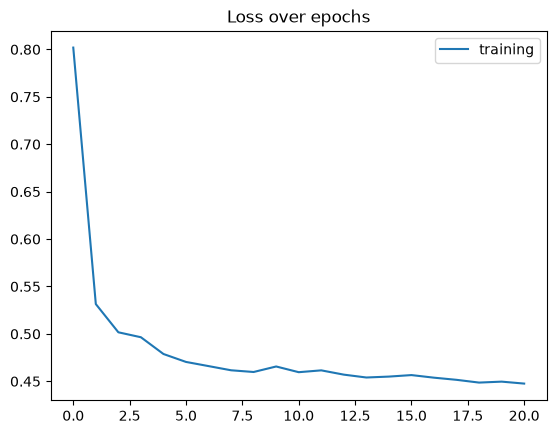

In [11]:
from matplotlib import pyplot as plt

plt.plot(loss_iters,label='training')
plt.legend()
plt.title('Loss over epochs')
plt.show()


There are definitely some problems encountered here. For one, we only used numeric data. Another problem: we did not normalize the numeric data before input to the neural network. We already know that can cause initialization issues for neural nets. 

**[Back to Slides]**
__________

## Using Torch Embeddings
For this particular optimization, we want to add some cusotmization in the way we process the data, allowing the model to treat each input slightly differently. Lets start by using embeddings for each input categorical feature. 

## Embedding Categorical Data
In order to add one-hot encoding, we need to separate the categorical features that are currently saved as integers and place them into Embedding layers. An embedding layer deals with integers as if they were one-hot encoded. To start, let's only create a model from these categorical variables. 

- The first decision to make is about the size of the dense feature embeddings. This is essentially a dimensionality reduction step. 
 - This can be difficult to set, but one common setting is $\log_2(N)$ or $\sqrt{N}$ where $N$ is the total number of uniques values.
- When using an Embedding, we can leave the variables represented as integers. That is, keras will use the integer representation to figure out how to one-hot-encode the variable. This is great because it means we don't need to change the variable in memory.


In [12]:
# get integer encodings for each string 
embedding_sizes = {}
for col in categorical_headers:
    tmp = LabelEncoder()
    df_train[col+'_int'] = tmp.fit_transform(df_train[col])
    df_test[col+'_int'] = tmp.transform(df_test[col])
    num_classes = len(tmp.classes_)
    emb_dim = int(np.sqrt(num_classes + 1))
    embedding_sizes[col+'_int'] = (num_classes,emb_dim)
    print(f'{col} will embed from {num_classes} to {emb_dim}.')
    
# need to redefine the dataset to include cataegorical variables
class AdultEmbeddingDataset(Dataset):
    def __init__(self, df):
        # separate the 
        cat_cols = [x+'_int' for x in categorical_headers]
        self.X_num = torch.tensor(df[numeric_headers].to_numpy().astype(float), dtype=torch.float32)
        self.X_cat = torch.tensor(df[cat_cols].to_numpy(), dtype=torch.long) # LongTensor for embeddings
        self.y = torch.tensor(df.income.to_numpy(), dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.y)
        
    def __getitem__(self, idx):
        return self.X_num[idx], self.X_cat[idx], self.y[idx]

train_loader = DataLoader(AdultEmbeddingDataset(df_train), batch_size=64, shuffle=True)
test_loader = DataLoader(AdultEmbeddingDataset(df_test), batch_size=64, shuffle=False)

workclass will embed from 7 to 2.
education will embed from 16 to 4.
marital_status will embed from 7 to 2.
occupation will embed from 14 to 3.
relationship will embed from 6 to 2.
race will embed from 5 to 2.
sex will embed from 2 to 1.
country will embed from 41 to 6.


In [13]:
class IncomeEmbeddingClassifier(nn.Module):
    def __init__(self, embedding, num_numerical_cols):
        super().__init__()
        # Create an embedding layer for each categorical feature
        tmp = []
        total_emb_dim = 0
        for key, (vocab_size, embed_size) in embedding.items():
            tmp.append( nn.Embedding(vocab_size, embed_size) )
            total_emb_dim += embed_size
        self.embeddings = nn.ModuleList(tmp)
        
        # Calculate total dimensions entering the dense layer
        total_input_dim = total_emb_dim + num_numerical_cols
        
        self.net = nn.Sequential(
            nn.Linear(total_input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x_num, x_cat):
        # Pass each categorical feature through its respective embedding layer
        emb_outputs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        
        # Concatenate all embeddings and the raw numerical values together
        x_emb = torch.cat(emb_outputs, dim=1)
        x = torch.cat([x_num, x_emb], dim=1)
        
        return self.net(x)

model = IncomeEmbeddingClassifier(embedding_sizes, 4)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model       

IncomeEmbeddingClassifier(
  (embeddings): ModuleList(
    (0): Embedding(7, 2)
    (1): Embedding(16, 4)
    (2): Embedding(7, 2)
    (3): Embedding(14, 3)
    (4): Embedding(6, 2)
    (5): Embedding(5, 2)
    (6): Embedding(2, 1)
    (7): Embedding(41, 6)
  )
  (net): Sequential(
    (0): Linear(in_features=26, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Epoch 1 Loss: 1.2165 Test Accuracy: 0.7989
Epoch 6 Loss: 0.3588 Test Accuracy: 0.8378
Epoch 11 Loss: 0.3572 Test Accuracy: 0.8459
Epoch 16 Loss: 0.3640 Test Accuracy: 0.8497
Epoch 21 Loss: 0.3345 Test Accuracy: 0.8481


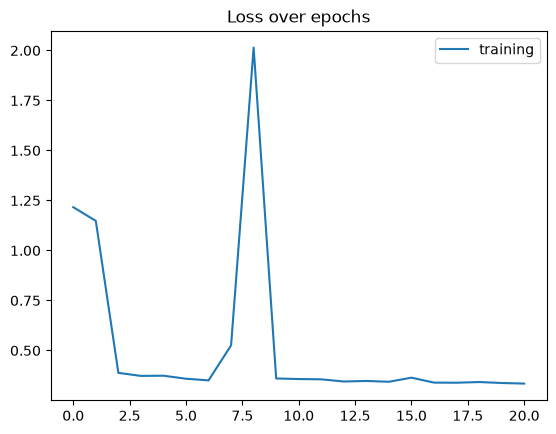

In [14]:
loss_iters = []
for epoch in range(21): # quick demonstration
    model.train()
    total_loss = 0
    for batch_num, batch_cat, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_num, batch_cat)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    loss_iters.append(total_loss / len(train_loader))
        
    if epoch%5 == 0: 
        # print out some results and testing, 
        print(f"Epoch {epoch+1} Loss: {loss_iters[-1]:.4f}", end=" ")

        predictions = []
        model.eval()
        with torch.no_grad():
            for batch_num, batch_cat, batch_y in test_loader:
                yhat = model(batch_num, batch_cat)
                ypreds = (yhat.detach().cpu().numpy()) > 0.50
                predictions.extend(ypreds)
    
            print(f"Test Accuracy: {mt.accuracy_score(df_test.income.to_numpy(), predictions):.4f}")

plt.plot(loss_iters,label='training')
plt.legend()
plt.title('Loss over epochs')
plt.show()

**[Back to Slides]**

__________

# Crossed Columns and Deep Embeddings
Lets create the network below in steps. This network consists of a number of different paths for the input data to take.
![asdfasfd](https://1.bp.blogspot.com/-Dw1mB9am1l8/V3MgtOzp3uI/AAAAAAAABGs/mP-3nZQCjWwdk6qCa5WraSpK8A7rSPj3ACLcB/s1600/image04.png)


## Making Crossed Columns
For this example, we are going to make embeddings for crossed columns. Tensorflow `feature_space` makes this operation very simple. 

In the model we will have: 
- branches of categorical features as input 
- branches of features that will be crossed (we deal with the same as categories)
- branches of numeric data input



In [15]:
# get integer encodings for each string 
embedding_sizes = {}
for col in categorical_headers:
    tmp = LabelEncoder()
    df_train[col+'_int'] = tmp.fit_transform(df_train[col])
    df_test[col+'_int'] = tmp.transform(df_test[col])
    num_classes = len(tmp.classes_)
    emb_dim = int(np.sqrt(num_classes + 1))
    embedding_sizes[col+'_int'] = (num_classes,emb_dim)
    print(f'{col} will embed from {num_classes} to {emb_dim}.')

# creat new string categories in the data
crossings =[('education','marital_status'),
            ('education','occupation')
           ]

crossed_columns = []
crossing_sizes = {}
for feat1, feat2 in crossings:
    col = f'{feat1}_x_{feat2}'
    df_train[col] = df_train[feat1].astype(str) + "_" + df_train[feat2].astype(str)
    df_test[col] = df_test[feat1].astype(str) + "_" + df_test[feat2].astype(str)
    
    crossed_columns.append(col)

    tmp = LabelEncoder()
    tmp.fit(pd.concat([df_train[col], df_test[col]], ignore_index=True))
    df_train[col+'_int'] = tmp.transform(df_train[col])
    df_test[col+'_int'] = tmp.transform(df_test[col])
    num_classes = len(tmp.classes_)
    emb_dim = int(np.sqrt(num_classes + 1))
    crossing_sizes[col+'_int'] = (num_classes,emb_dim)
    print(f'{col} will embed from {num_classes} to {emb_dim}.')
    
    
# need to redefine the dataset to include cataegorical variables
class AdultCrossedDataset(Dataset):
    def __init__(self, df):
        # separate the categorical and feature crossings
        cat_cols = [x+'_int' for x in categorical_headers]
        crs_cols = [x+'_int' for x in crossed_columns]
        self.X_num = torch.tensor(df[numeric_headers].to_numpy().astype(float), dtype=torch.float32)
        self.X_cat = torch.tensor(df[cat_cols].to_numpy(), dtype=torch.long) # LongTensor for embeddings
        self.X_crs = torch.tensor(df[crs_cols].to_numpy(), dtype=torch.long) # LongTensor for embeddings
        self.y = torch.tensor(df.income.to_numpy(), dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.y)
        
    def __getitem__(self, idx):
        return self.X_num[idx], self.X_cat[idx], self.X_crs[idx], self.y[idx]

train_loader = DataLoader(AdultCrossedDataset(df_train), batch_size=64, shuffle=True)
test_loader = DataLoader(AdultCrossedDataset(df_test), batch_size=64, shuffle=False)

workclass will embed from 7 to 2.
education will embed from 16 to 4.
marital_status will embed from 7 to 2.
occupation will embed from 14 to 3.
relationship will embed from 6 to 2.
race will embed from 5 to 2.
sex will embed from 2 to 1.
country will embed from 41 to 6.
education_x_marital_status will embed from 104 to 10.
education_x_occupation will embed from 205 to 14.


___


## Combining Crossed Linear Classifier and Deep Embeddings
Now its just a matter of setting the wide and deep columns for tensorflow. After which, we can use the combined classifier!

Wide and deep models can have really interesting and useful properties so they are great to keep in mind when selecting an architecture. Some of the hyperparameters that are specific to this are:
- which features to cross together, typically you only want to cross columns you think are important to be connected--they somehow might create new knowledge by combining.
- the size of the dense feature embeddings. This can be difficult to set, but one common setting is $log_2(N)$ or $\sqrt{N}$ where $N$ is the total number of uniques values.

In [16]:
class IncomeWideDeepClassifier(nn.Module):
    def __init__(self, embedding, crossing, num_numerical_cols):
        super().__init__()
        # Create an embedding layer for each categorical feature
        tmp = []
        total_emb_dim = 0
        for key, (vocab_size, embed_size) in embedding.items():
            tmp.append( nn.Embedding(vocab_size, embed_size) )
            total_emb_dim += embed_size
        self.embeddings = nn.ModuleList(tmp)

        
        # Calculate total dimensions entering the deep network
        total_input_dim = total_emb_dim + num_numerical_cols
        
        self.deep_net = nn.Sequential(
            nn.Linear(total_input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
        )

        # Create an embedding layer for each feature crossing
        tmp = []
        total_crs_dim = 0
        for key, (vocab_size, embed_size) in crossing.items():
            tmp.append( nn.Embedding(vocab_size, embed_size) )
            total_crs_dim += embed_size
        self.crossings = nn.ModuleList(tmp)

        self.wide_net = nn.Sequential(
            nn.Linear(total_crs_dim, 8),
        )

        self.classify_net = nn.Sequential(
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x_num, x_cat, x_crs):
        # Pass each categorical feature through its respective embedding layer
        emb_outputs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        
        # Concatenate all embeddings and the raw numerical values together
        x_emb = torch.cat(emb_outputs, dim=1)
        x = torch.cat([x_num, x_emb], dim=1)

        dx = self.deep_net(x)

        crs_outputs = [emb(x_crs[:, i]) for i, emb in enumerate(self.crossings)]
        x_emb_crs = torch.cat(crs_outputs, dim=1)
        cx = self.wide_net(x_emb_crs)

        x = torch.cat([dx, cx], dim=1)
        
        return self.classify_net(x)

model = IncomeWideDeepClassifier(embedding_sizes, crossing_sizes, 4)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model     

IncomeWideDeepClassifier(
  (embeddings): ModuleList(
    (0): Embedding(7, 2)
    (1): Embedding(16, 4)
    (2): Embedding(7, 2)
    (3): Embedding(14, 3)
    (4): Embedding(6, 2)
    (5): Embedding(5, 2)
    (6): Embedding(2, 1)
    (7): Embedding(41, 6)
  )
  (deep_net): Sequential(
    (0): Linear(in_features=26, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=8, bias=True)
  )
  (crossings): ModuleList(
    (0): Embedding(104, 10)
    (1): Embedding(205, 14)
  )
  (wide_net): Sequential(
    (0): Linear(in_features=24, out_features=8, bias=True)
  )
  (classify_net): Sequential(
    (0): Linear(in_features=16, out_features=1, bias=True)
    (1): Sigmoid()
  )
)

Epoch 1 Loss: 0.4419 Test Accuracy: 0.8291
Epoch 6 Loss: 0.3295 Test Accuracy: 0.8479
Epoch 11 Loss: 0.3297 Test Accuracy: 0.8464
Epoch 16 Loss: 0.3261 Test Accuracy: 0.8488
Epoch 21 Loss: 0.3234 Test Accuracy: 0.8509


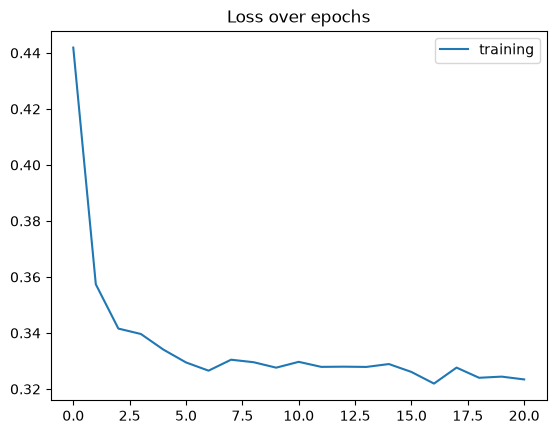

In [17]:
loss_iters = []
for epoch in range(21): # quick demonstration
    model.train()
    total_loss = 0
    for batch_num, batch_cat, batch_crs, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_num, batch_cat, batch_crs)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    loss_iters.append(total_loss / len(train_loader))
        
    if epoch%5 == 0: 
        # print out some results and testing, 
        print(f"Epoch {epoch+1} Loss: {loss_iters[-1]:.4f}", end=" ")

        predictions = []
        model.eval()
        with torch.no_grad():
            for batch_num, batch_cat, batch_crs, batch_y in test_loader:
                yhat = model(batch_num, batch_cat, batch_crs)
                ypreds = (yhat.detach().cpu().numpy()) > 0.50
                predictions.extend(ypreds)
    
            print(f"Test Accuracy: {mt.accuracy_score(df_test.income.to_numpy(), predictions):.4f}")

plt.plot(loss_iters,label='training')
plt.legend()
plt.title('Loss over epochs')
plt.show()


_____
# Making Generalization Better
In what ways might we try to make the model found generalize more concretely?

**Self Test:** What is the best method to make the results better?  
- A. Add Dropout to deep network
- B. Add Dropout to wide network
- C. Perturb the Categorical Data during Training (augmentation)
- D. Add L2 regularization to different layer's weights



In [21]:
class IncomeWideDeepClassifierWithDropout(nn.Module):
    def __init__(self, embedding, crossing, num_numerical_cols):
        super().__init__()
        # Create an embedding layer for each categorical feature
        tmp = []
        total_emb_dim = 0
        for key, (vocab_size, embed_size) in embedding.items():
            tmp.append( nn.Embedding(vocab_size, embed_size) )
            total_emb_dim += embed_size
        self.embeddings = nn.ModuleList(tmp)

        
        # Calculate total dimensions entering the deep network
        total_input_dim = total_emb_dim + num_numerical_cols
        
        self.deep_net = nn.Sequential(
            nn.Linear(total_input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.Dropout(p=0.1),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.Dropout(p=0.25),
        )

        # Create an embedding layer for each feature crossing
        tmp = []
        total_crs_dim = 0
        for key, (vocab_size, embed_size) in crossing.items():
            tmp.append( nn.Embedding(vocab_size, embed_size) )
            total_crs_dim += embed_size
        self.crossings = nn.ModuleList(tmp)

        self.wide_net = nn.Sequential(
            nn.Linear(total_crs_dim, 8),
        )

        self.classify_net = nn.Sequential(
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x_num, x_cat, x_crs):
        # Pass each categorical feature through its respective embedding layer
        emb_outputs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        
        # Concatenate all embeddings and the raw numerical values together
        x_emb = torch.cat(emb_outputs, dim=1)
        x = torch.cat([x_num, x_emb], dim=1)

        dx = self.deep_net(x)

        crs_outputs = [emb(x_crs[:, i]) for i, emb in enumerate(self.crossings)]
        x_emb_crs = torch.cat(crs_outputs, dim=1)
        cx = self.wide_net(x_emb_crs)

        x = torch.cat([dx, cx], dim=1)
        
        return self.classify_net(x)

model = IncomeWideDeepClassifierWithDropout(embedding_sizes, crossing_sizes, 4)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model     

IncomeWideDeepClassifierWithDropout(
  (embeddings): ModuleList(
    (0): Embedding(7, 2)
    (1): Embedding(16, 4)
    (2): Embedding(7, 2)
    (3): Embedding(14, 3)
    (4): Embedding(6, 2)
    (5): Embedding(5, 2)
    (6): Embedding(2, 1)
    (7): Embedding(41, 6)
  )
  (deep_net): Sequential(
    (0): Linear(in_features=26, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): Dropout(p=0.1, inplace=False)
    (6): ReLU()
    (7): Linear(in_features=16, out_features=8, bias=True)
    (8): Dropout(p=0.25, inplace=False)
  )
  (crossings): ModuleList(
    (0): Embedding(104, 10)
    (1): Embedding(205, 14)
  )
  (wide_net): Sequential(
    (0): Linear(in_features=24, out_features=8, bias=True)
  )
  (classify_net): Sequential(
    (0): Linear(in_features=16, out_features=1, bias=True)
    (1): Sigmoid()
  )
)

Epoch 1 Loss: 0.4709 Test Accuracy: 0.8355
Epoch 6 Loss: 0.3348 Test Accuracy: 0.8503
Epoch 11 Loss: 0.3260 Test Accuracy: 0.8500
Epoch 16 Loss: 0.3255 Test Accuracy: 0.8486
Epoch 21 Loss: 0.3317 Test Accuracy: 0.8492
Epoch 26 Loss: 0.3268 Test Accuracy: 0.8487
Epoch 31 Loss: 0.3262 Test Accuracy: 0.8493


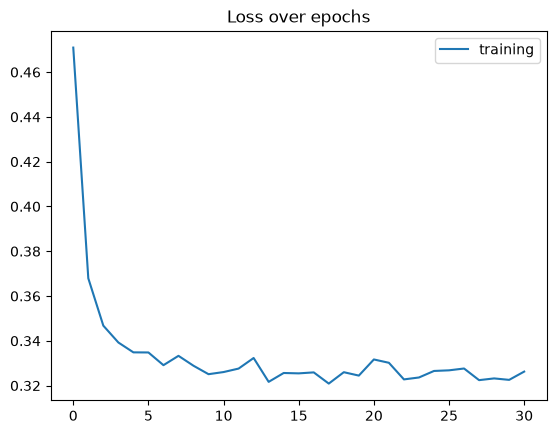

In [22]:
loss_iters = []
for epoch in range(31): # quick demonstration
    model.train()
    total_loss = 0
    for batch_num, batch_cat, batch_crs, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_num, batch_cat, batch_crs)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    loss_iters.append(total_loss / len(train_loader))
        
    if epoch%5 == 0: 
        # print out some results and testing, 
        print(f"Epoch {epoch+1} Loss: {loss_iters[-1]:.4f}", end=" ")

        predictions = []
        model.eval()
        with torch.no_grad():
            for batch_num, batch_cat, batch_crs, batch_y in test_loader:
                yhat = model(batch_num, batch_cat, batch_crs)
                ypreds = (yhat.detach().cpu().numpy()) > 0.50
                predictions.extend(ypreds)
    
            print(f"Test Accuracy: {mt.accuracy_score(df_test.income.to_numpy(), predictions):.4f}")

plt.plot(loss_iters,label='training')
plt.legend()
plt.title('Loss over epochs')
plt.show()

# In this Notebook You Learned
- The Torch API
- Embedding layers in Torch
- Wide and Deep networks
- Customizing Pytorch for wide/deep networks